In [ ]:
#Ejecutar el codigo secuencialmente
#Graficar
import matplotlib.pyplot as plt

In [ ]:
# 1. DATOS INICIALES DEL PROBLEMA
# Población inicial en el tiempo t=0
x0 = 10

# Listas de candidatos del problema
r_candidatos = [0.1, 0.2, 0.3, 0.4]
K_candidatos = [50, 80, 100, 120]

# Datos reales que observó (del tiempo t=0 al t=5)
# len es longitud de la lista
datos_reales = [10, 12, 15, 19, 24, 30]
total_dias = len(datos_reales)

# 2. VARIABLES PARA GUARDAR EL MEJOR RESULTADO
mejor_error_global = 999999.0  # Empezamos con un error muy alto
mejor_r = 0 # Inicializamos en 0
mejor_K = 0
mejor_secuencia_poblacion = []

# Variables de optimización
pasos_con_poda = 0
pasos_totales_fuerza_bruta = len(r_candidatos) * len(K_candidatos) * (total_dias - 1)
# Se resta 1 por que el total de dias es 6 pero el dia 0 no se calcula, siendo solo 5

In [ ]:
print("--- INICIANDO CALIBRACIÓN CON BACKTRACKING ---")

# 3. PROBAR TODAS LAS COMBINACIONES DE R Y K
# Usamos ciclos anidados para probar todos las posibles combinaciones de candidatos
# Son almenos 16 combinaciones posibles (4x4)
# Estudiarle la complejidad al algoritmo, dado el copdigo en el peor de los casos cual es la complejidad por backtracking, añadirle una diapositiva ala presentacion con la notacion Landau o (O GRANDE)
# contar que se aprendio de esta notacion, para que sirve y en este proyecto como lo implementamos.
for r in r_candidatos:
    for K in K_candidatos:

        # Preparamos la simulación para cada iteracion
        # Cada vez que el algoritmo cambia a un nuevo par de (r, K) necesita resetear el experimento con los valores iniciales
        poblacion_actual = x0
        error_acumulado = 0
        secuencia_actual = [x0] # La inicializamos asi para luego guardarle todos los valores y hacer la grafica.
        hubo_poda = False

        # Simular día a día (desde el día 1 hasta el 5)
        for t in range(1, total_dias):
            pasos_con_poda = pasos_con_poda + 1 # Calcula cuantos pasos hace, inicializa en 1 por lo mismo

            # Aplicamos la fórmula matemática del EcoModelo
            # x(t+1) = x(t) + r*x(t)*(1 - x(t)/K)
            siguiente_poblacion = poblacion_actual + (r * poblacion_actual * (1 - (poblacion_actual / K)))
            # x(t) seria Poblacion_actual
            # x(t+1) seria Siguiente_poblacion

            # --- RESTRICCIÓN 1: PODA POR VALOR NEGATIVO ---
            if siguiente_poblacion < 0:
                print(f"Población negativa con r={r} y K={K} en el día {t}. Rompemos el ciclo.")
                hubo_poda = True
                break # Aqui ocurre el RETROCESO (Backtracking)

            # Calculamos el error de este día (distancia entre lo real y la simulación)
            # Aqui comparamos el error respecto a los datos reales usando valor absoluto para no darle importancia al signo
            error_del_paso = abs(siguiente_poblacion - datos_reales[t])
            error_acumulado = error_acumulado + error_del_paso # Determina el valor del error global de estos candidatos

            # Guardamos el valor calculado en nuestra lista temporal
            secuencia_actual.append(siguiente_poblacion)
            # Sirve para guardar los resultados de todo y graficarlos

            # --- RESTRICCIÓN 2: PODA POR ERROR ALTO ---
            if error_acumulado >= mejor_error_global:
                # Si ya es peor que el mejor error que conocemos, no tiene sentido calcular los días que faltan
                # Es decir si ya tenemos una solución mejor, evadimos este calculo y seguimos buscando
                hubo_poda = True
                break # Aqui ocurre el RETROCESO (Backtracking)

            # Si no se podó, avanzamos el día para el siguiente cálculo
            poblacion_actual = siguiente_poblacion

        # 4. EVALUAR SI ESTA COMBINACIÓN COMPLETA FUE LA MEJOR
        # Si llego hasta aqui los candidatos pasaron por todas las restricciones sin falla
        if hubo_poda == False:
            print(f"Combinación válida terminada -> r: {r}, K: {K} | Error Total: {round(error_acumulado, 2)}")
            # Round funciona para redondear los decimales a el parametro puesto
            # Si encontramos un error más pequeño que nuestro error actual, lo guardamos
            # Basicamente si encontramos un error mas bajo guardamos todos sus datos para continuar en base a ese
            if error_acumulado < mejor_error_global:
                mejor_error_global = error_acumulado
                mejor_r = r
                mejor_K = K
                mejor_secuencia_poblacion = secuencia_actual

In [ ]:
# 5. MOSTRAR RESULTADOS FINALES EN CONSOLA
print("\n=========================================")
print("RESULTADOS DE LA CALIBRACIÓN:")
print(f"El mejor parámetro r es: {mejor_r}")
print(f"El mejor parámetro K es: {mejor_K}")
print(f"El menor error logrado fue: {round(mejor_error_global, 2)}")
print(f"Secuencia simulada ganadora: {[round(n, 2) for n in mejor_secuencia_poblacion]}")
print(f"Secuencia real observada : {datos_reales}")
print("=========================================")
print(f"Pasos calculados con Fuerza Bruta: {pasos_totales_fuerza_bruta}")
print(f"Pasos calculados con Backtracking (Poda): {pasos_con_poda}")
print(f"Ahorro computacional: {round((1 - (pasos_con_poda / pasos_totales_fuerza_bruta)) * 100, 2)}%")
print("=========================================")

In [ ]:
# 6. GENERAR LA GRÁFICA PARA EL INFORME Y BEAMER
plt.figure(figsize=(8, 5))
# Línea de los datos reales
plt.plot(datos_reales, marker='o', color='blue', label='Datos Reales (Biólogo)')
# Línea de nuestra mejor simulación
plt.plot(mejor_secuencia_poblacion, marker='x', linestyle='--', color='red',
         label=f'Mejor Simulación (r={mejor_r}, K={mejor_K})')

plt.title('Calibración del EcoModelo usando Backtracking')
plt.xlabel('Tiempo (Días)')
plt.ylabel('Cantidad de Población')
plt.legend()
plt.grid(True)
plt.show()

--- INICIANDO CALIBRACIÓN CON BACKTRACKING ---
Combinación válida terminada -> r: 0.1, K: 50 | Error Total: 37.07
Combinación válida terminada -> r: 0.1, K: 80 | Error Total: 35.54
Combinación válida terminada -> r: 0.1, K: 100 | Error Total: 35.02
Combinación válida terminada -> r: 0.1, K: 120 | Error Total: 34.67
Combinación válida terminada -> r: 0.2, K: 50 | Error Total: 22.47
Combinación válida terminada -> r: 0.2, K: 80 | Error Total: 18.41
Combinación válida terminada -> r: 0.2, K: 100 | Error Total: 16.97
Combinación válida terminada -> r: 0.2, K: 120 | Error Total: 15.99
Combinación válida terminada -> r: 0.3, K: 50 | Error Total: 7.82
Combinación válida terminada -> r: 0.3, K: 80 | Error Total: 3.01

RESULTADOS DE LA CALIBRACIÓN:
El mejor parámetro r es: 0.3
El mejor parámetro K es: 80
El menor error logrado fue: 3.01
Secuencia simulada ganadora: [10, 12.62, 15.81, 19.62, 24.06, 29.11]
Secuencia real observada : [10, 12, 15, 19, 24, 30]
Pasos calculados con Fuerza Bruta: 80
P

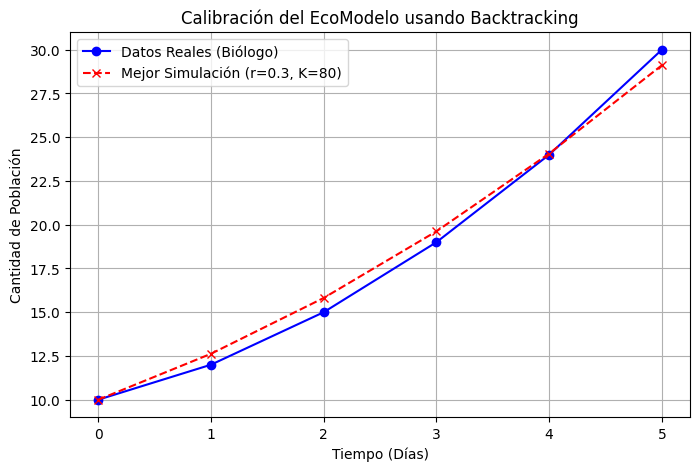

In [ ]:
#CODIGO COMPLETO DE RESERVA EN CASO DE ERROR.
import matplotlib.pyplot as plt

# 1. DATOS INICIALES DEL PROBLEMA
# Población inicial en el tiempo t=0
x0 = 10

# Listas de candidatos del problema
r_candidatos = [0.1, 0.2, 0.3, 0.4]
K_candidatos = [50, 80, 100, 120]

# Datos reales que observó (del tiempo t=0 al t=5)
# len es longitud de la lista
datos_reales = [10, 12, 15, 19, 24, 30]
total_dias = len(datos_reales)

# 2. VARIABLES PARA GUARDAR EL MEJOR RESULTADO
mejor_error_global = 999999.0  # Empezamos con un error muy alto
mejor_r = 0 # Inicializamos en 0
mejor_K = 0
mejor_secuencia_poblacion = []

# Variables de optimización
pasos_con_poda = 0
pasos_totales_fuerza_bruta = len(r_candidatos) * len(K_candidatos) * (total_dias - 1)
# Se resta 1 por que el total de dias es 6 pero el dia 0 no se calcula, siendo solo 5
#------
print("--- INICIANDO CALIBRACIÓN CON BACKTRACKING ---")

# 3. PROBAR TODAS LAS COMBINACIONES DE R Y K
# Usamos ciclos anidados para probar todos las posibles combinaciones de candidatos
# Son almenos 16 combinaciones posibles (4x4)
# Estudiarle la complejidad al algoritmo, dado el copdigo en el peor de los casos cual es la complejidad por backtracking, añadirle una diapositiva ala presentacion con la notacion Landau o (O GRANDE)
# contar que se aprendio de esta notacion, para que sirve y en este proyecto como lo implementamos.
for r in r_candidatos:
    for K in K_candidatos:

        # Preparamos la simulación para cada iteracion
        # Cada vez que el algoritmo cambia a un nuevo par de (r, K) necesita resetear el experimento con los valores iniciales
        poblacion_actual = x0
        error_acumulado = 0
        secuencia_actual = [x0] # La inicializamos asi para luego guardarle todos los valores y hacer la grafica.
        hubo_poda = False

        # Simular día a día (desde el día 1 hasta el 5)
        for t in range(1, total_dias):
            pasos_con_poda = pasos_con_poda + 1 # Calcula cuantos pasos hace, inicializa en 1 por lo mismo

            # Aplicamos la fórmula matemática del EcoModelo
            # x(t+1) = x(t) + r*x(t)*(1 - x(t)/K)
            siguiente_poblacion = poblacion_actual + (r * poblacion_actual * (1 - (poblacion_actual / K)))
            # x(t) seria Poblacion_actual
            # x(t+1) seria Siguiente_poblacion

            # --- RESTRICCIÓN 1: PODA POR VALOR NEGATIVO ---
            if siguiente_poblacion < 0:
                print(f"Población negativa con r={r} y K={K} en el día {t}. Rompemos el ciclo.")
                hubo_poda = True
                break # Aqui ocurre el RETROCESO (Backtracking)

            # Calculamos el error de este día (distancia entre lo real y la simulación)
            # Aqui comparamos el error respecto a los datos reales usando valor absoluto para no darle importancia al signo
            error_del_paso = abs(siguiente_poblacion - datos_reales[t])
            error_acumulado = error_acumulado + error_del_paso # Determina el valor del error global de estos candidatos

            # Guardamos el valor calculado en nuestra lista temporal
            secuencia_actual.append(siguiente_poblacion)
            # Sirve para guardar los resultados de todo y graficarlos

            # --- RESTRICCIÓN 2: PODA POR ERROR ALTO ---
            if error_acumulado >= mejor_error_global:
                # Si ya es peor que el mejor error que conocemos, no tiene sentido calcular los días que faltan
                # Es decir si ya tenemos una solución mejor, evadimos este calculo y seguimos buscando
                hubo_poda = True
                break # Aqui ocurre el RETROCESO (Backtracking)

            # Si no se podó, avanzamos el día para el siguiente cálculo
            poblacion_actual = siguiente_poblacion

        # 4. EVALUAR SI ESTA COMBINACIÓN COMPLETA FUE LA MEJOR
        # Si llego hasta aqui los candidatos pasaron por todas las restricciones sin falla
        if hubo_poda == False:
            print(f"Combinación válida terminada -> r: {r}, K: {K} | Error Total: {round(error_acumulado, 2)}")
            # Round funciona para redondear los decimales a el parametro puesto
            # Si encontramos un error más pequeño que nuestro error actual, lo guardamos
            # Basicamente si encontramos un error mas bajo guardamos todos sus datos para continuar en base a ese
            if error_acumulado < mejor_error_global:
                mejor_error_global = error_acumulado
                mejor_r = r
                mejor_K = K
                mejor_secuencia_poblacion = secuencia_actual
#------
# 5. MOSTRAR RESULTADOS FINALES EN CONSOLA
print("\n=========================================")
print("RESULTADOS DE LA CALIBRACIÓN:")
print(f"El mejor parámetro r es: {mejor_r}")
print(f"El mejor parámetro K es: {mejor_K}")
print(f"El menor error logrado fue: {round(mejor_error_global, 2)}")
print(f"Secuencia simulada ganadora: {[round(n, 2) for n in mejor_secuencia_poblacion]}")
print(f"Secuencia real observada : {datos_reales}")
print("=========================================")
print(f"Pasos calculados con Fuerza Bruta: {pasos_totales_fuerza_bruta}")
print(f"Pasos calculados con Backtracking (Poda): {pasos_con_poda}")
print(f"Ahorro computacional: {round((1 - (pasos_con_poda / pasos_totales_fuerza_bruta)) * 100, 2)}%")
print("=========================================")
#------
# 6. GENERAR LA GRÁFICA PARA EL INFORME Y BEAMER
plt.figure(figsize=(8, 5))
# Línea de los datos reales
plt.plot(datos_reales, marker='o', color='blue', label='Datos Reales (Biólogo)')
# Línea de nuestra mejor simulación
plt.plot(mejor_secuencia_poblacion, marker='x', linestyle='--', color='red',
         label=f'Mejor Simulación (r={mejor_r}, K={mejor_K})')

plt.title('Calibración del EcoModelo usando Backtracking')
plt.xlabel('Tiempo (Días)')
plt.ylabel('Cantidad de Población')
plt.legend()
plt.grid(True)
plt.show()
#-----